In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from imblearn.under_sampling import RandomUnderSampler
import lightgbm as lgb

# 1. Preparação dos Dados
def limpar_nomes(df):
    df.columns = [re.sub(r'[^\w\s]', '_', col).replace(' ', '_') for col in df.columns]
    return df

df = pd.read_csv('dados_arrumados.csv')
df = limpar_nomes(df)

target = 'HadHeartAttack'
features_criadas = ['ComorbidityCount', 'HighRiskLifestyle']
bases_originais_nomes = [
    'HadAngina', 'HadStroke', 'HadAsthma', 'HadSkinCancer', 'HadCOPD', 
    'HadDepressiveDisorder', 'HadKidneyDisease', 'HadArthritis', 'HadDiabetes',
    'SmokerStatus', 'PhysicalActivities', 'AlcoholDrinkers'
]

# Identifica as colunas (incluindo dummies) que pertencem às bases originais
cols_originais_com_dummies = [col for col in df.columns if any(col.startswith(base) for base in bases_originais_nomes)]

# 2. Função de Comparação de Cenários
def avaliar_cenarios(X, y, titulo_cenario):
    print(f"\n{'='*40}\nEXECUTANDO: {titulo_cenario}\n{'='*40}")
    
    # Split Estratificado
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
    
    # UnderSampling para equilibrar o aprendizado
    rus = RandomUnderSampler(random_state=42)
    X_tr_res, y_tr_res = rus.fit_resample(X_train, y_train)
    
    # Escalonamento para Logística
    scaler = MinMaxScaler()
    X_tr_res_scaled = scaler.fit_transform(X_tr_res)
    X_test_scaled = scaler.transform(X_test)
    
    modelos = [
        (LogisticRegression(max_iter=1000, random_state=42), "Logistic", True),
        (RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42), "Random Forest", False),
        (lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1), "LightGBM", False)
    ]
    
    resultados_plot = []
    
    for model, name, use_scaled in modelos:
        X_train_curr = X_tr_res_scaled if use_scaled else X_tr_res
        X_test_curr = X_test_scaled if use_scaled else X_test
        
        model.fit(X_train_curr, y_tr_res)
        y_pred = model.predict(X_test_curr)
        y_prob = model.predict_proba(X_test_curr)[:, 1]
        
        print(f"\n[{name}] ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")
        print(classification_report(y_test, y_pred, digits=3))
        
        resultados_plot.append((name, y_test, y_pred))
    
    # Plotagem das Matrizes de Confusão
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, y_true, y_p) in zip(axes, resultados_plot):
        cm = confusion_matrix(y_true, y_p)
        ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f"{name}")
    plt.suptitle(f"Matrizes de Confusão - {titulo_cenario}")
    plt.tight_layout()
    plt.show()



EXECUTANDO: Cenário: Somente Originais

[Logistic] ROC AUC: 0.8897
              precision    recall  f1-score   support

           0      0.985     0.837     0.905    101917
           1      0.207     0.770     0.326      5627

    accuracy                          0.834    107544
   macro avg      0.596     0.803     0.616    107544
weighted avg      0.944     0.834     0.875    107544


[Random Forest] ROC AUC: 0.8851
              precision    recall  f1-score   support

           0      0.987     0.804     0.886    101917
           1      0.184     0.801     0.299      5627

    accuracy                          0.803    107544
   macro avg      0.585     0.802     0.592    107544
weighted avg      0.945     0.803     0.855    107544


[LightGBM] ROC AUC: 0.8892
              precision    recall  f1-score   support

           0      0.986     0.815     0.892    101917
           1      0.191     0.792     0.308      5627

    accuracy                          0.814    107544

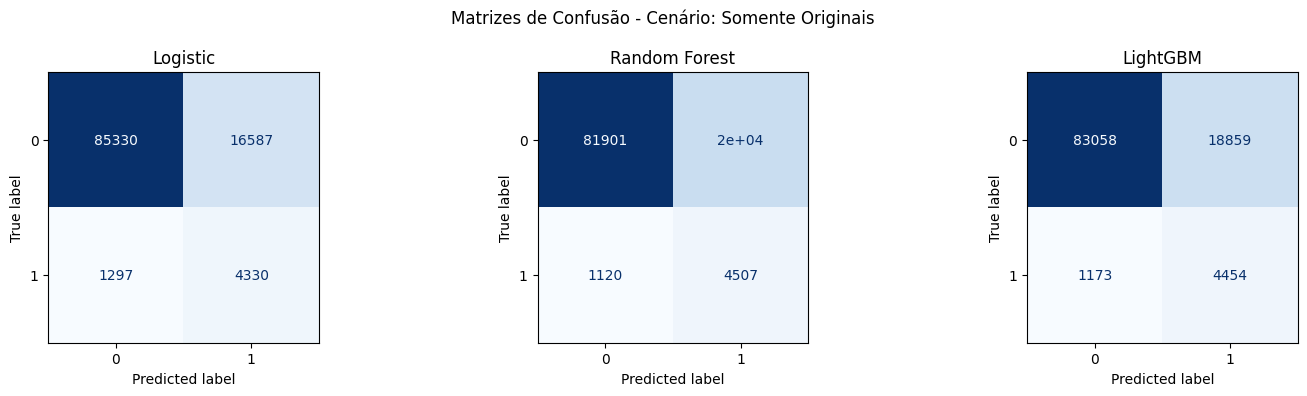

In [2]:
# 3. Execução dos 3 Cenários

y = df[target]

# --- CENÁRIO 1: Somente Originais ---
# Remove as features criadas
X_1 = df.drop(columns=[target] + features_criadas)
avaliar_cenarios(X_1, y, "Cenário: Somente Originais")



EXECUTANDO: Cenário: Somente Criadas

[Logistic] ROC AUC: 0.7736
              precision    recall  f1-score   support

           0      0.979     0.714     0.826    101917
           1      0.122     0.717     0.208      5627

    accuracy                          0.714    107544
   macro avg      0.550     0.715     0.517    107544
weighted avg      0.934     0.714     0.793    107544


[Random Forest] ROC AUC: 0.7734
              precision    recall  f1-score   support

           0      0.979     0.714     0.826    101917
           1      0.122     0.717     0.208      5627

    accuracy                          0.714    107544
   macro avg      0.550     0.715     0.517    107544
weighted avg      0.934     0.714     0.793    107544


[LightGBM] ROC AUC: 0.7735
              precision    recall  f1-score   support

           0      0.979     0.714     0.826    101917
           1      0.122     0.717     0.208      5627

    accuracy                          0.714    107544
 

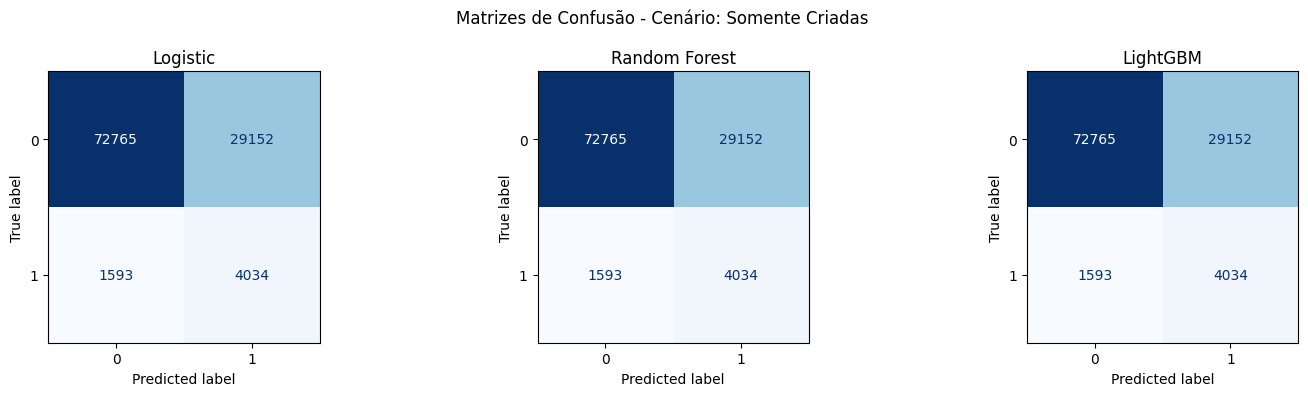

In [3]:
# --- CENÁRIO 2: Somente Criadas ---
# Remove todas as colunas que deram origem às criadas
X_2 = df.drop(columns=[target] + cols_originais_com_dummies)
# Garante que as criadas estão lá (caso tenham sido removidas por engano no drop anterior)
X_2 = df[features_criadas] 
avaliar_cenarios(X_2, y, "Cenário: Somente Criadas")


EXECUTANDO: Cenário: Híbrido (Originais + Criadas)

[Logistic] ROC AUC: 0.8896
              precision    recall  f1-score   support

           0      0.985     0.837     0.905    101917
           1      0.207     0.770     0.326      5627

    accuracy                          0.833    107544
   macro avg      0.596     0.803     0.616    107544
weighted avg      0.944     0.833     0.875    107544


[Random Forest] ROC AUC: 0.8857
              precision    recall  f1-score   support

           0      0.986     0.805     0.886    101917
           1      0.184     0.798     0.299      5627

    accuracy                          0.804    107544
   macro avg      0.585     0.801     0.593    107544
weighted avg      0.944     0.804     0.855    107544


[LightGBM] ROC AUC: 0.8886
              precision    recall  f1-score   support

           0      0.986     0.814     0.892    101917
           1      0.190     0.790     0.306      5627

    accuracy                          0.8

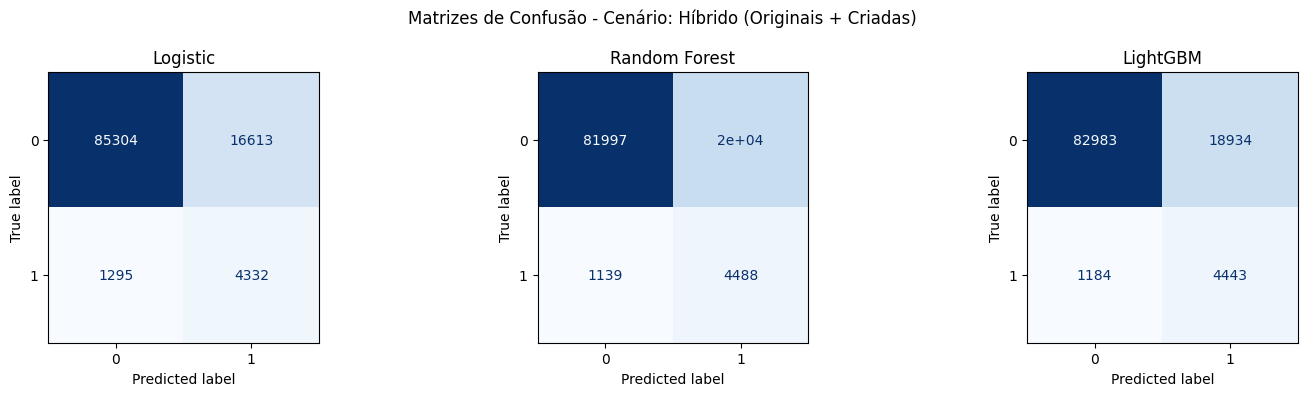

In [4]:
# --- CENÁRIO 3: Híbrido (Tudo) ---
X_3 = df.drop(columns=[target])
avaliar_cenarios(X_3, y, "Cenário: Híbrido (Originais + Criadas)")

Importância do Recall: Em um contexto médico, o Recall (~80%) é a métrica mais importante. Como o custo de um Falso Negativo (não detectar um ataque cardíaco) é potencialmente fatal, o uso de Under-Sampling foi essencial para garantir que o modelo identifique a grande maioria dos pacientes em risco, ainda que ao custo de mais alarmes falsos.

Poder da Feature Engineering: As variáveis criadas (ComorbidityCount e HighRiskLifestyle) demonstraram alto valor preditivo, entregando 0.77 de AUC de forma isolada. Isso prova que a síntese de informações biológicas complexas em indicadores simples funciona como um excelente "atalho" para o diagnóstico.
